In [12]:
import equinox as eqx
import jax.numpy as jnp
import pandas as pd
import warnings

from dmm.config_options import Conf
from dmm.initialisation import get_features_filepath, process_features_and_setup_models
from dmm.training_helper_funcs import create_pypesto_problem, rmse

from common import FEATURES_OUTFILE
from dataclasses import replace
from evaluation_utils import load_model
from util import load_petab_base_files
from training_configuration import SPLITS

warnings.filterwarnings("ignore")


In [13]:
def set_param_to_zero(
        model,
        param
):
    # Find parameter deviation index
    param_idx = model.parameter_deviation_names.index(param)
    # Extract binary mask and convert to JAX array
    new_output_sparsity_binary_mask = jnp.array(model.output_sparsity_binary_mask)
    # Set value to zero and convert back to tuple format
    new_output_sparsity_binary_mask = new_output_sparsity_binary_mask.at[param_idx].set(0)
    new_output_sparsity_binary_mask = tuple(new_output_sparsity_binary_mask.tolist())
    # Replace inside model and return new model instance
    return eqx.tree_at(
        lambda model: model.output_sparsity_binary_mask,
        model,
        new_output_sparsity_binary_mask,
    )

In [11]:
from tqdm import tqdm

conf = Conf(
    model = "EGFR_MAPK__logobs_tegfr_aggavg",  # base model
    data = "dream_cytof",
    n_hidden = 6,
    depth = 0,
    dropout_rate=0.1,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    recon_loss=1e-4,
    n_epoch=500,
    multiheaded=False,
    max_lrate=0.01,
    lrate_span=1.0,
    lrate_decay=1.0,
    warmup_fct=0.0,
    opt_steps=10,
    opt_mult=2,
    weight_decay=0.0,
    momentum=0.9,
    use_simple_linear_schedule=True
)

# parameters_interest = [
#     "EGFR_p_Y1173_EGF_0_kw",
#     "ERBB2_p_Y1248_EGFR__Y1173_p_kw",
#     "ERBB2_p_Y1248_ERBB2_kw"
# ]
parameters_interest = None


# Load petab_base_files (once only)
petab_base_files = load_petab_base_files(conf)


res = []
for context, feature_sel in zip(
        [
            "cytof_init",
            "multimodal"
        ],
        [
            "RFE_15_permute",
            "RFE_10_permute"
        ]
):
    subconf = replace(conf, context=context, features=feature_sel)
    if context == "multimodal":
        subconf = replace(subconf, multiheaded=True)
    for samples in sorted(SPLITS):
        print(f"Now analysing {context}, {samples}...")
        subconf = replace(subconf, samples=samples)
        # Get filepaths for features and feature transformation pipeline
        features_filepath = get_features_filepath(subconf, FEATURES_OUTFILE)

        for job in range(10):
            subconf = replace(subconf, job=job)
            (
                _,
                problem,
                pypesto_subproblems,
                features,
            ) = process_features_and_setup_models(
                conf=subconf,
                features_filepath=features_filepath,
                petab_base_files=petab_base_files,
                dataset="train+val",
            )

            model = load_model(subconf, pypesto_subproblems["train"])
            print(f"Model loaded successfully for job {job}.")

            # Get list of parameter deviation names to perturb
            if parameters_interest is None:
                parameters_interest = model.parameter_deviation_names

            pypesto_problems = {
                dataset: create_pypesto_problem(pypesto_subproblems[dataset])
                for dataset in ["train", "val"]
            }

            # Precompute pristine RMSEs once per dataset
            rmse_pristine = {}
            for dataset in ["train", "val"]:
                rmse_pristine[dataset] = float(rmse(pypesto_problems[dataset], model, features[dataset].values))

            for param in tqdm(parameters_interest):
                new_model = set_param_to_zero(
                    model, param
                )
                for dataset in ["train", "val"]:
                    rmse_zeroed = rmse(pypesto_problems[dataset], new_model, features[dataset].values)
                    res.append(
                        {
                            "context": context,
                            "samples": samples,
                            "job": job,
                            "param": param,
                            "dataset": dataset,
                            "rmse_pristine": rmse_pristine[dataset],
                            "rmse_zeroed": rmse_zeroed,
                            "rmse_diff": rmse_zeroed - rmse_pristine[dataset],
                        }
                    )

results = pd.DataFrame(res)

Now analysing cytof_init, BT20...


KeyError: 'MED_EGFR_endo_EGF_0_kw'

In [21]:
results.to_csv("sensitivity_analysis_cytof_init_multimodal_base_p38_nhidden6.csv", index=False)

In [39]:
import pandas as pd
results_df = pd.read_csv("sensitivity_analysis_cytof_init_multimodal_base_p38_nhidden6.csv")
# Look at multimodal, validation
val_results = results_df[
    (results_df.dataset == "val") & (results_df.context == "multimodal")
]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

In [40]:
val_results

param,EGFR_deg_EGF_0_kw,EGFR_deg_bact,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_endo_EGFR_kw,EGFR_endo_ERBB2_kw,EGFR_endo_ERK__Y204_p_kw,EGFR_endo_bact,EGFR_p_Y1173_EGF_0_kw,EGFR_p_Y1173_bact,...,MEK_p_S222_bact,MEK_p_S222_iMEK_0_kw,RPS6KA1_dp_S380_kcat,RPS6KA1_p_S380_ERK__Y204_p_kw,RPS6KA1_p_S380_bact,TOPK_dp_Y74_kcat,TOPK_p_Y74_EGFR__Y1173_p_kw,TOPK_p_Y74_ERBB2__Y1248_p_kw,TOPK_p_Y74_ERBB3__Y1289_p_kw,TOPK_p_Y74_bact
samples,,,,,,,,,,,,,,,,,,,,,
BT20,0.031509,0.000000,0.000467,0.008586,-0.002221,0.000000,-0.002979,0.000128,0.000000,0.000000e+00,...,0.000000,0.000000,0.000410,0.002568,0.000000,0.0,1.672037e-05,0.000000,0.0,0.000000
EVSAT,0.000000,0.000000,-0.002840,0.004349,-0.005217,0.000000,-0.004341,0.000000,0.000000,-8.668604e-07,...,-0.004238,0.000000,-0.004200,0.144495,-0.008697,0.0,3.714094e-05,0.000000,0.0,0.000000
HCC1500,0.120860,0.000000,-0.000155,0.000000,0.000000,0.015565,0.000000,0.006971,0.007010,0.000000e+00,...,0.000000,0.000000,0.006118,0.149036,0.000000,0.0,7.645517e-02,0.001322,0.0,0.000000
HCC2185,0.003197,0.000000,0.001929,0.005257,0.000151,0.000000,-0.000261,-0.000012,0.000000,0.000000e+00,...,-0.000125,0.000000,-0.003887,0.077850,0.000000,0.0,0.000000e+00,0.000000,0.0,0.000000
MCF7,0.000000,0.000000,0.029349,0.030149,0.000000,0.000000,0.000000,0.000000,0.025892,0.000000e+00,...,0.006235,0.003048,0.000000,-0.011589,-0.007688,0.0,5.773289e-02,-0.004067,0.0,-0.002055
UACC3199,0.005540,0.000000,-0.001339,0.000000,0.000000,0.002180,0.000000,0.000191,-0.020556,2.750215e-03,...,0.000000,0.000000,0.000000,0.066243,0.000000,0.0,2.476387e-07,0.000004,0.0,0.000000
UACC893,0.000000,0.000138,0.000000,0.000000,0.000000,0.000000,0.000040,0.000000,0.000000,0.000000e+00,...,0.000000,-0.000647,-0.005421,0.204741,-0.065869,0.0,0.000000e+00,0.000000,0.0,0.000000


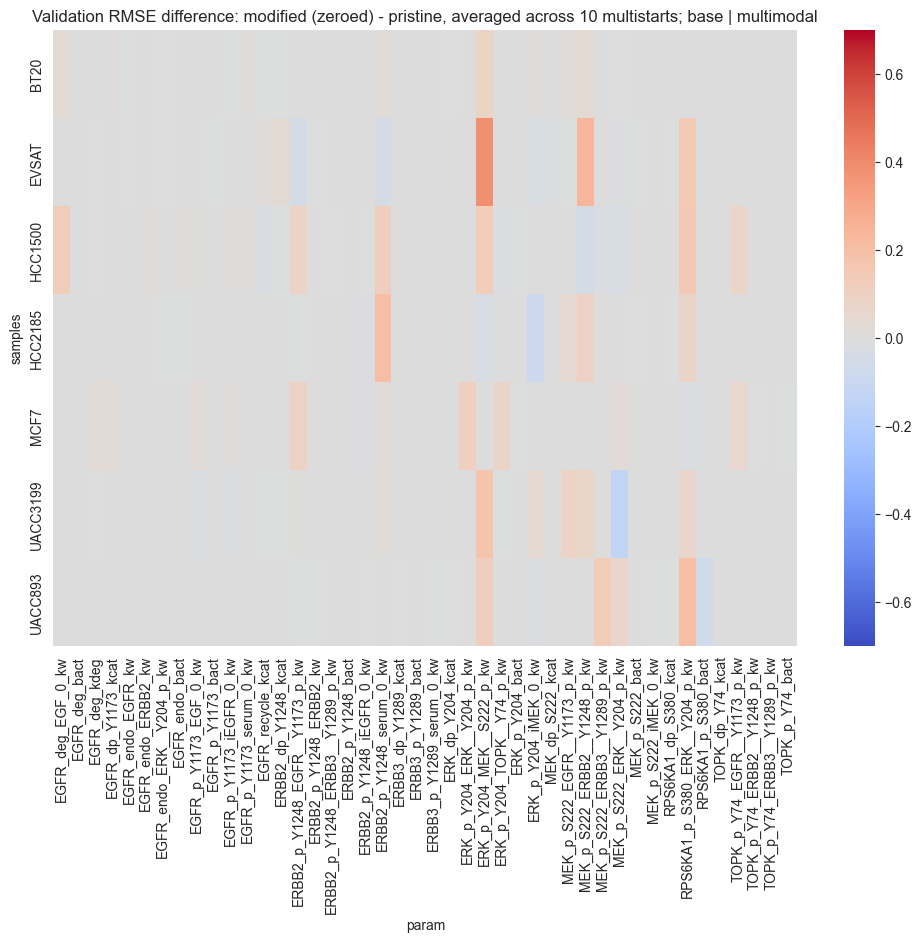

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | multimodal");
# plt.savefig("sensitivity_analysis_multimodal_base_p38_nhidden6.png")

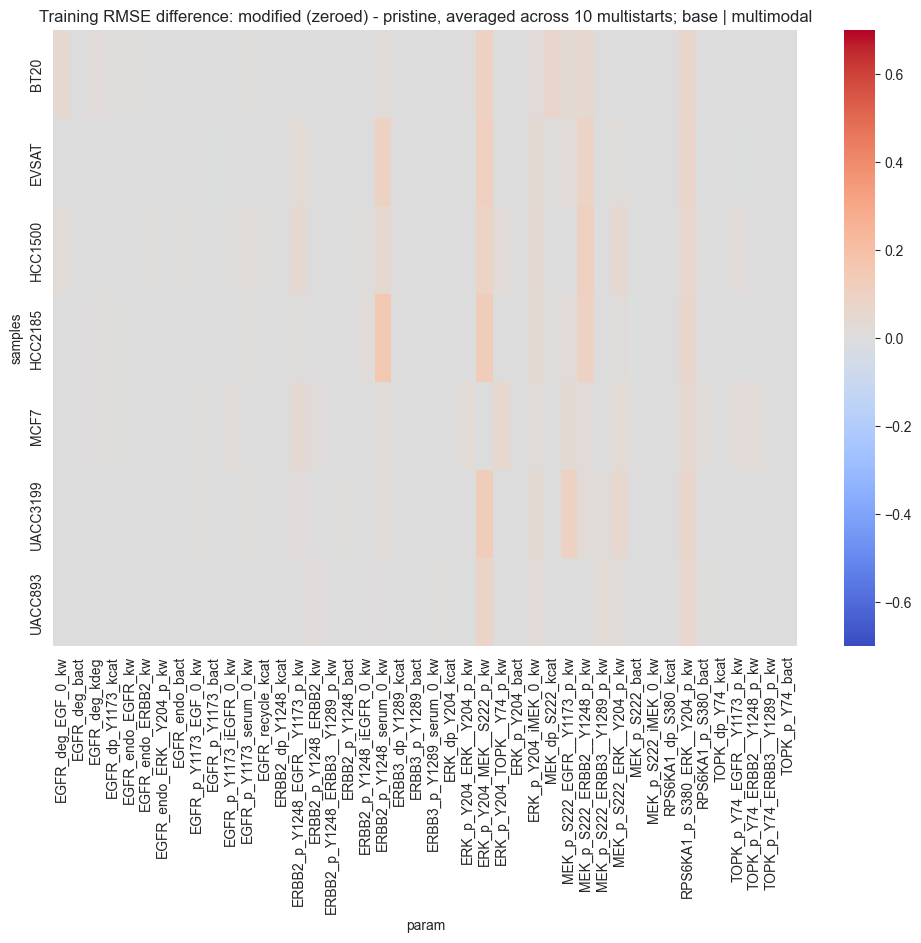

In [42]:
# Look at multimodal, validation
train_results = results_df[
    (results_df.dataset == "train") & (results_df.context == "multimodal")
]

train_results = pd.pivot_table(
    train_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(train_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=train_results.columns)
plt.title("Training RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | multimodal");
# plt.savefig("sensitivity_analysis_multimodal_base_p38_nhidden6_train.png")

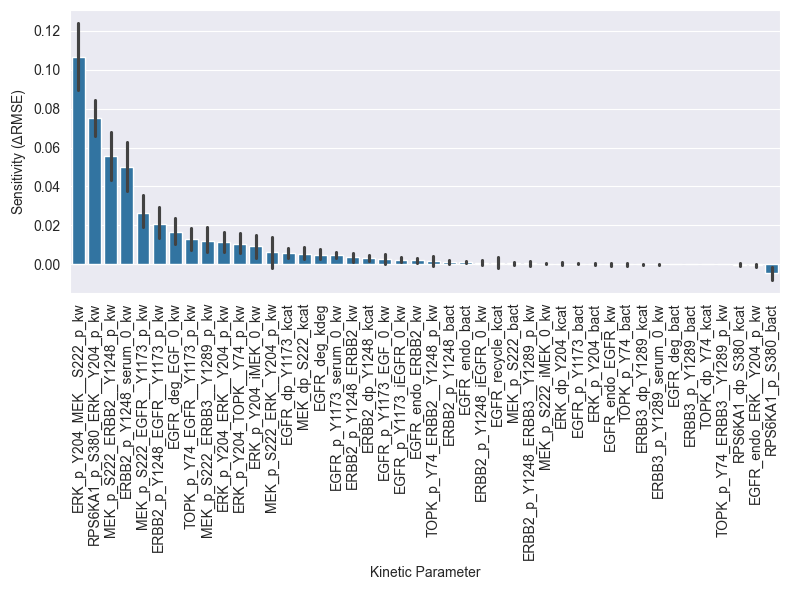

In [43]:
# filter to multimodal context
df = results_df[results_df.context == "multimodal"]

# compute mean rmse_diff per param
order = (
    df.groupby("param")["rmse_diff"]
      .mean()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(8, 6))
# plot with that order
sns.barplot(
    data=df,
    x="param",
    y="rmse_diff",
    order=order,
)

plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
plt.xlabel("Kinetic Parameter")
plt.xticks(rotation=90)
plt.tight_layout()
# plt.savefig("mean_samples_sensitivity_multimodal_base_p38_nhidden6.pdf")

plt.show()

In [ ]:
def get_receptor_grouping(results_df: pd.DataFrame) -> pd.DataFrame:
    results_df["receptor_group"] = results_df["param"].apply(classify_param)
    return results_df

In [44]:
import re

def classify_param(name):
    # Match EGFR only when preceded and followed by non-letters or boundary
    egfr = re.search(r'(?<![A-Za-z])EGFR(?![A-Za-z])', name)
    erbb2 = re.search(r'(?<![A-Za-z])ERBB2(?![A-Za-z])', name)

    if egfr and not erbb2:
        return "EGFR"
    elif erbb2 and not egfr:
        return "ERBB2"
    elif egfr and erbb2:
        return "EGFR+ERBB2"
    else:
        return "Other"

results_df["receptor_group"] = results_df["param"].apply(classify_param)

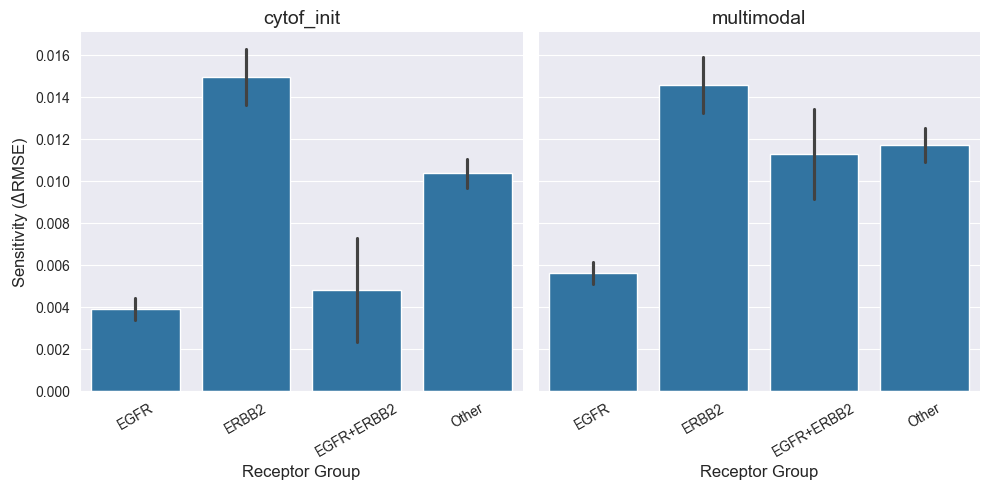

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: pretty names for contexts
context_labels = {
    "cytof_init": "cytof_init",
    "multimodal": "multimodal"
}

# Create FacetGrid
g = sns.FacetGrid(
    results_df,
    col="context",
    col_order=["cytof_init", "multimodal"],
    height=5,
    sharey=True,
)

# Plot barplots
g.map_dataframe(
    sns.barplot,
    x="receptor_group",
    y="rmse_diff",
    order=["EGFR", "ERBB2", "EGFR+ERBB2", "Other"],
    errorbar="se"   # optional if you have uncertainty
)

# Set axis labels
g.set_axis_labels("Receptor Group", r"Sensitivity ($\Delta$RMSE)", fontsize=12)

# Improve facet titles
for ax, context in zip(g.axes.flat, ["cytof_init", "multimodal"]):
    ax.set_title(context_labels[context], fontsize=14)

# Optional: rotate x labels for readability
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()